# Extreme Precipitation Forecasting with GraphCast — Tennessee Valley Flood

GraphCast forecast of the April 2025 Tennessee Valley Flood using Earth2Studio. Initialized on April 1 with a 6-day forecast covering April 1–6, 2025. The heaviest rain was on April 3, with reports of 153 mm/day in the Tennessee Valley.

In [38]:
# Configuration

EVENT_NAME = "2025 Tennessee Valley Flood"
EVENT_DATE = "2025-04-03"

FORECAST_INIT = "2025-04-01T00:00:00"
NSTEPS = 28  # 6 days + buffer to cover through April 6

# Tennessee Valley region
EXTENT = [-95, -82, 33, 40.5]

OUTPUT_DIR = "tn_flood_outputs"
ZARR_STORE = f"{OUTPUT_DIR}/graphcast_tn_flood.zarr"

# Nashville, TN
POI_LAT = 36.16
POI_LON = 360 - 86.78
POI_LABEL = "Nashville, TN"

DATES = ["2025-04-01", "2025-04-02", "2025-04-03", "2025-04-04", "2025-04-05", "2025-04-06"]

CITIES = [
    {"lat": 39.78, "lon": 360 - 89.65, "label": "Springfield, IL"},
    {"lat": 39.77, "lon": 360 - 86.16, "label": "Indianapolis, IN"},
    {"lat": 39.10, "lon": 360 - 84.51, "label": "Cincinnati, OH"},
    {"lat": 38.63, "lon": 360 - 90.20, "label": "St Louis, MO"},
    {"lat": 38.25, "lon": 360 - 85.76, "label": "Louisville, KY"},
    {"lat": 36.37, "lon": 360 - 94.21, "label": "Bentonville, AR"},
    {"lat": 35.15, "lon": 360 - 90.05, "label": "Memphis, TN"},
]

In [2]:
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch

import earth2studio.run as run
from earth2studio.models.px import GraphCastOperational
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
Device: cuda


In [3]:
package = GraphCastOperational.load_default_package()
model = GraphCastOperational.load_model(package)

data = GFS()

print("Model and data source loaded.")

Model and data source loaded.


In [4]:
io = ZarrBackend(ZARR_STORE, backend_kwargs={"overwrite": True})

io = run.deterministic(
    [FORECAST_INIT],
    NSTEPS,
    model,
    data,
    io,
    output_coords={"variable": np.array(["tp06"])},
)

print(io.root.tree())

2026-04-16 15:47:44.352 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-16 15:47:44.353 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-16 15:47:44.425 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 291283807-919289
2026-04-16 15:47:44.460 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 309598649-1260367
2026-04-16 15:47:44.478 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 313248268-922057
2026-04-16 15:47:44.494 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 344495606-1239285
2026-04-16 15:47:44.511 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 348154313-951718
2026-04-16 15:47:44.527 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GF

Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-16 15:47:44.560 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 372435965-960080
2026-04-16 15:47:44.577 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 158151103-734035
2026-04-16 15:47:44.593 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 402379849-1222579
2026-04-16 15:47:44.610 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250331/18/atmos/gfs.t18z.pgrb2.0p25.f000 405517211-978162


...

Fetching GFS data: 100%|██████████| 82/82 [00:01<00:00, 62.50it/s]


2026-04-16 15:47:47.472 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250401/00/atmos/gfs.t00z.pgrb2.0p25.f000 266961690-821340
2026-04-16 15:47:47.488 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250401/00/atmos/gfs.t00z.pgrb2.0p25.f000 245849423-718431
2026-04-16 15:47:47.505 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250401/00/atmos/gfs.t00z.pgrb2.0p25.f000 223876527-733654
2026-04-16 15:47:47.521 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250401/00/atmos/gfs.t00z.pgrb2.0p25.f000 213055301-740365
2026-04-16 15:47:48.110 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-16 15:47:48.142 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   3%|▎         | 1/29 [00:02<01:18,  2.79s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 29/29 [01:33<00:00,  3.23s/it]

2026-04-16 15:49:21.850 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (721,) float64
├── lead_time (29,) timedelta64
├── lon (1440,) float64
├── time (1,) datetime64
└── tp06 (1, 29, 721, 1440) float32

In [35]:
def compute_daily_total_precip(io, target_date, init_time, variable="tp06", dt_hours=6):
    """Compute total precipitation (mm) for a specific date."""
    steps_per_day = 24 // dt_hours
    day_start = np.datetime64(target_date)
    init = np.datetime64(init_time)

    first_step = int((day_start - init) / np.timedelta64(dt_hours, "h"))
    first_step = max(first_step, 1)

    last_available = io[variable].shape[1] - 1
    last_step = min(first_step + steps_per_day, last_available + 1)

    if first_step > last_available:
        raise ValueError(f"Target date {target_date} is beyond the forecast range.")

    total = np.zeros_like(io[variable][0, first_step])
    for s in range(first_step, last_step):
        total += io[variable][0, s] * 1000.0

    return np.clip(total, 0, None)


def compute_cumulative_precip(io, dates, init_time, variable="tp06", dt_hours=6):
    """Compute cumulative precipitation (mm) over multiple dates."""
    cumulative = None
    for date in dates:
        daily = compute_daily_total_precip(io, date, init_time, variable, dt_hours)
        if cumulative is None:
            cumulative = daily.copy()
        else:
            cumulative += daily
    return cumulative


In [40]:
def plot_daily_precip(precip_mm, io, target_date, extent, init_time, poi=None, model_name="GraphCast", save_path=None):
    """Plot daily total precipitation on a regional map."""
    plt.close("all")

    lon = io["lon"][:]
    lat = io["lat"][:]

    levels = [1, 5, 10, 20, 30, 50, 75, 100, 150]
    cmap = plt.cm.YlOrRd
    norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(12, 8),
    )

    im = ax.contourf(
        lon, lat, precip_mm,
        levels=levels, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(), extend="neither",
    )

    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.coastlines(linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    ax.set_extent(extent)

    if poi:
        for city in poi:
            ax.plot(
                city["lon"] - 360, city["lat"],
                marker="*", color="lime", markersize=8,
                markeredgecolor="black", markeredgewidth=0.5,
                transform=ccrs.PlateCarree(), zorder=5,
            )
            ax.text(
                city["lon"] - 360 + 0.15, city["lat"] + 0.15, city["label"],
                fontsize=7, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
                transform=ccrs.PlateCarree(), zorder=5,
            )

    cbar = plt.colorbar(im, ax=ax, shrink=0.55, pad=0.04, orientation="horizontal", extend = "neither")
    cbar.set_label("Total Precipitation (mm)")
    ax.set_title(
        f"{model_name} | Init: {init_time[:10]} | Date: {target_date}",
        fontsize=11,
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

### Daily Precipitation — April 1–6

Saved: tn_flood_outputs/graphcast_daily_2025-04-01.png


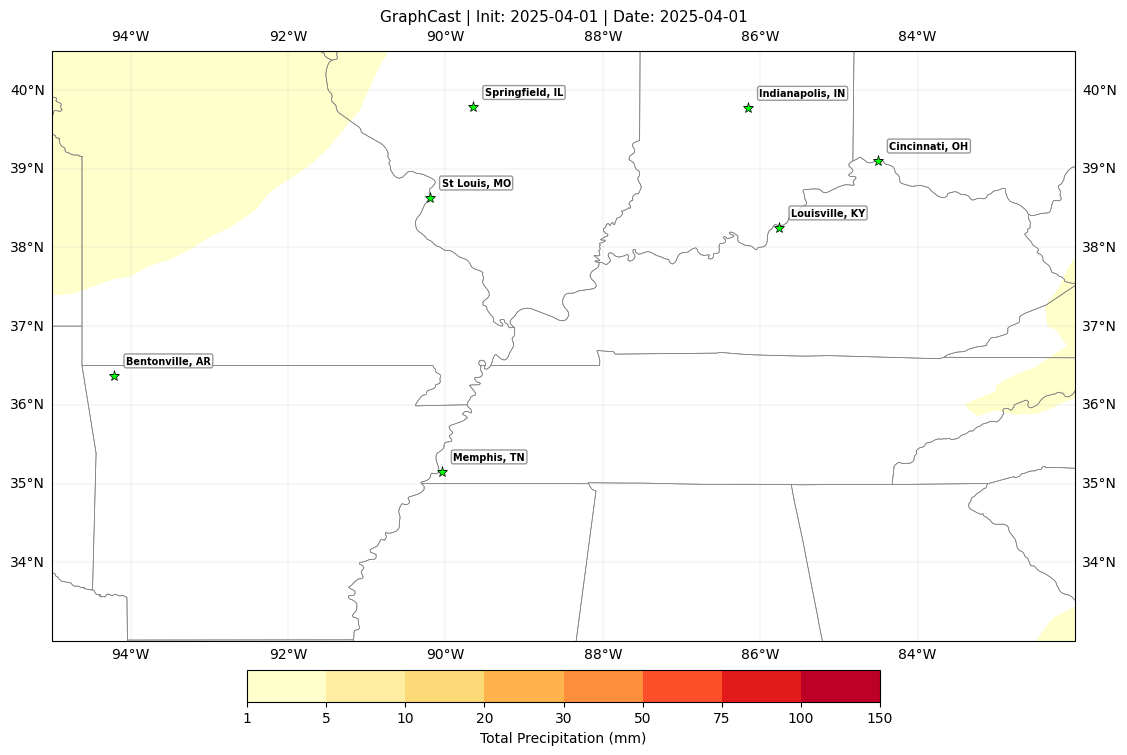

Saved: tn_flood_outputs/graphcast_daily_2025-04-02.png


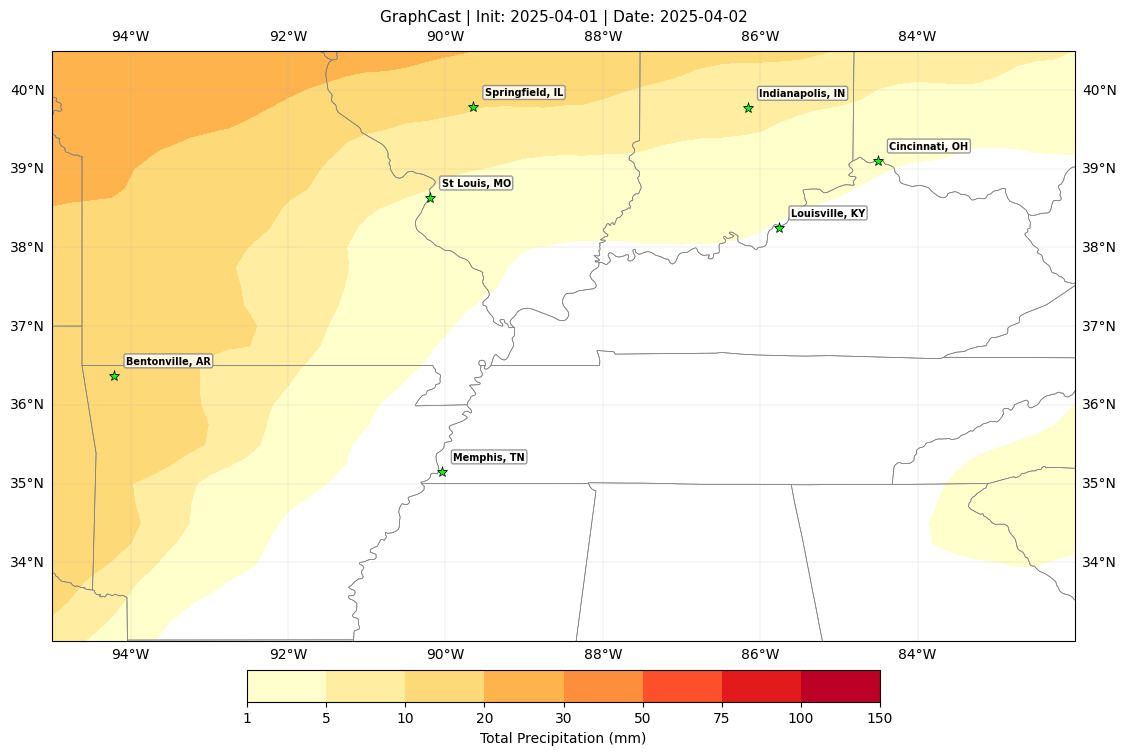

Saved: tn_flood_outputs/graphcast_daily_2025-04-03.png


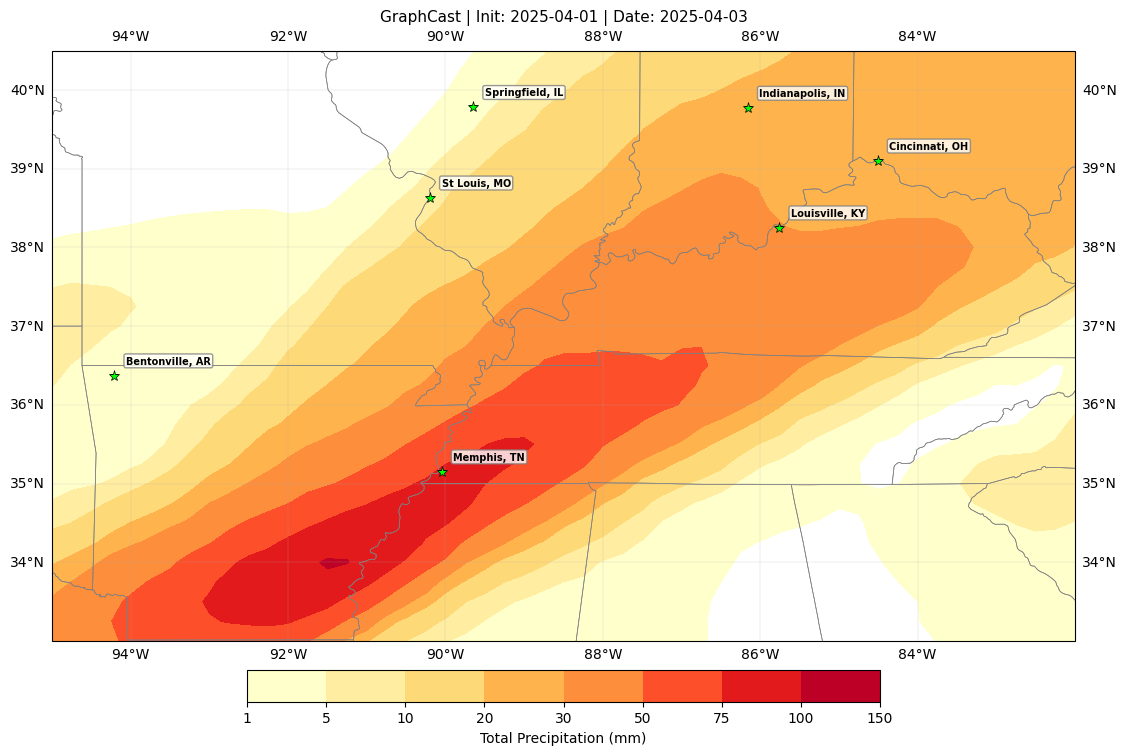

Saved: tn_flood_outputs/graphcast_daily_2025-04-04.png


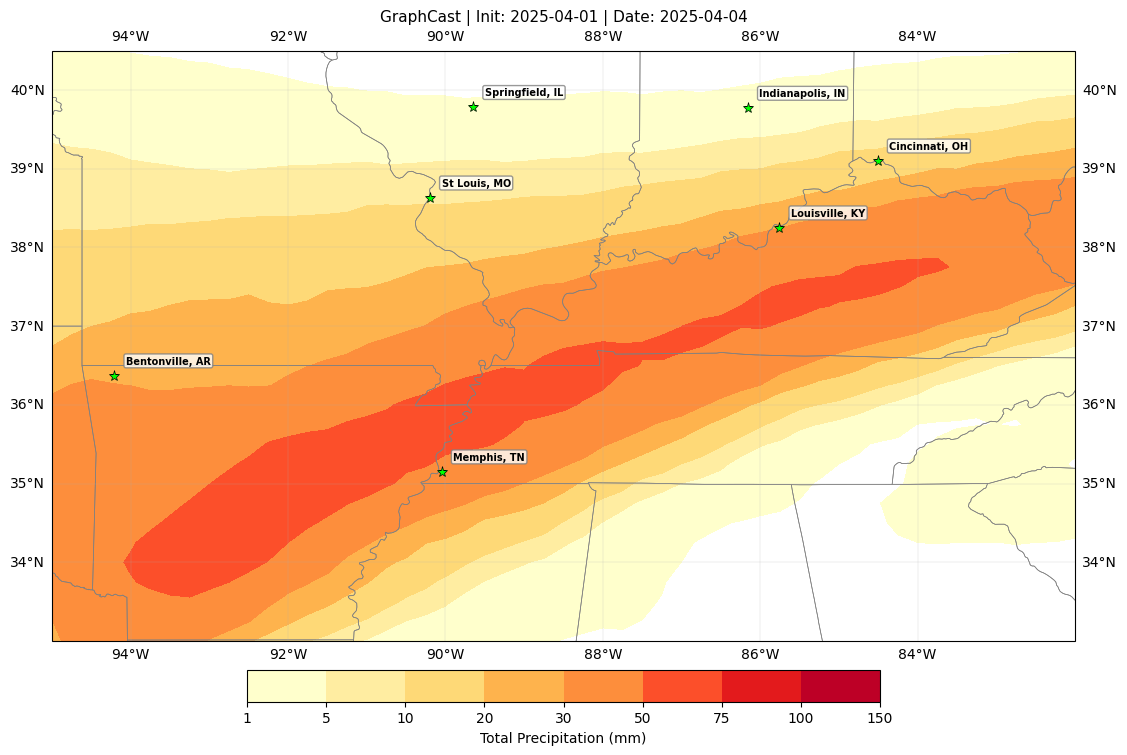

Saved: tn_flood_outputs/graphcast_daily_2025-04-05.png


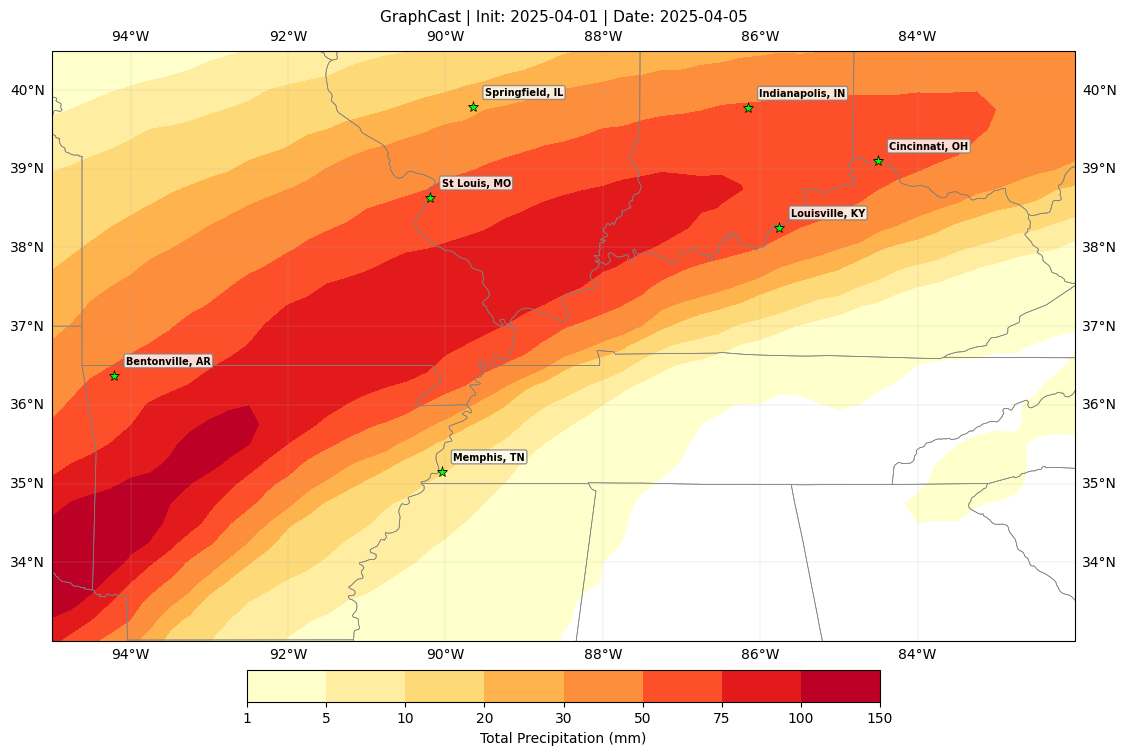

Saved: tn_flood_outputs/graphcast_daily_2025-04-06.png


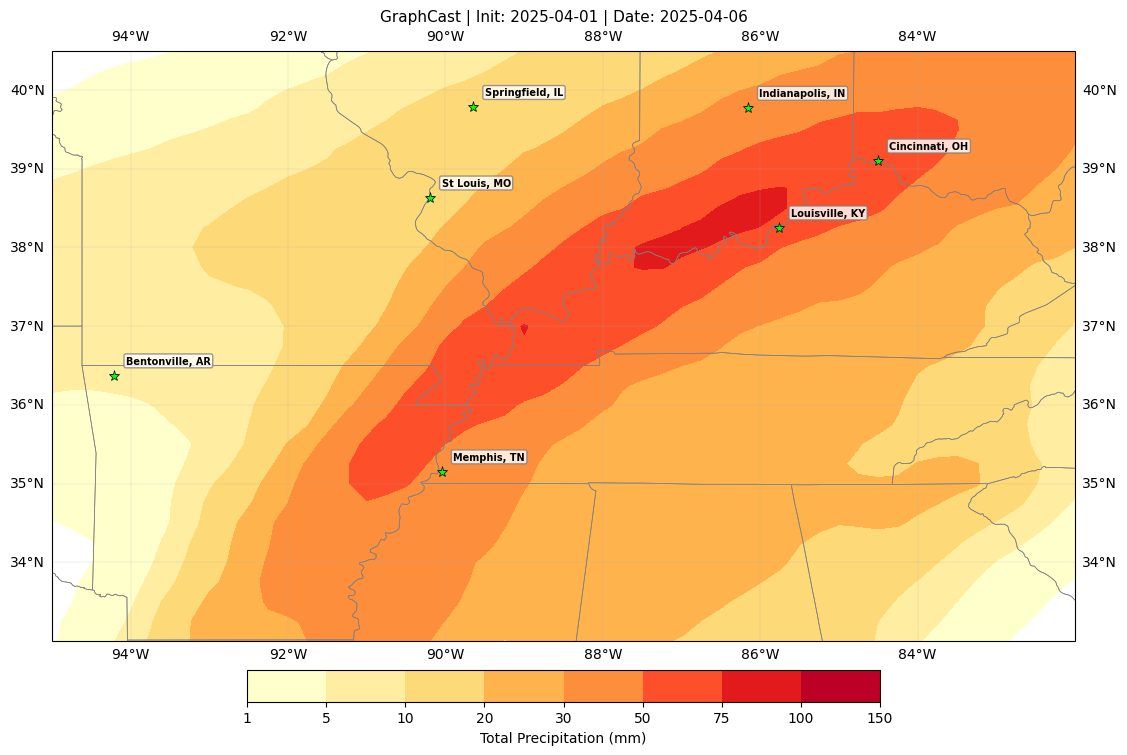

In [41]:
poi = {"lat": POI_LAT, "lon": POI_LON, "label": POI_LABEL}

for date in DATES:
    precip = compute_daily_total_precip(io, date, FORECAST_INIT)
    plot_daily_precip(
        precip, io, date, EXTENT, FORECAST_INIT, poi=CITIES,
        save_path=f"{OUTPUT_DIR}/graphcast_daily_{date}.png",
    )

### Daily Totals at Nashville

In [3]:
import numpy as np
lat_idx = np.argmin(np.abs(io["lat"][:] - POI_LAT))
lon_idx = np.argmin(np.abs(io["lon"][:] - POI_LON))


for date in DATES:
    precip = compute_daily_total_precip(io, date, FORECAST_INIT)
    val = precip[lat_idx, lon_idx]
    print(f"{date} | GraphCast: {val:6.2f} mm")

NameError: name 'io' is not defined

### Cumulative Precipitation — April 1–6

Saved: tn_flood_outputs/graphcast_cumulative_apr1_6.png

Cumulative at Nashville: 118.99 mm


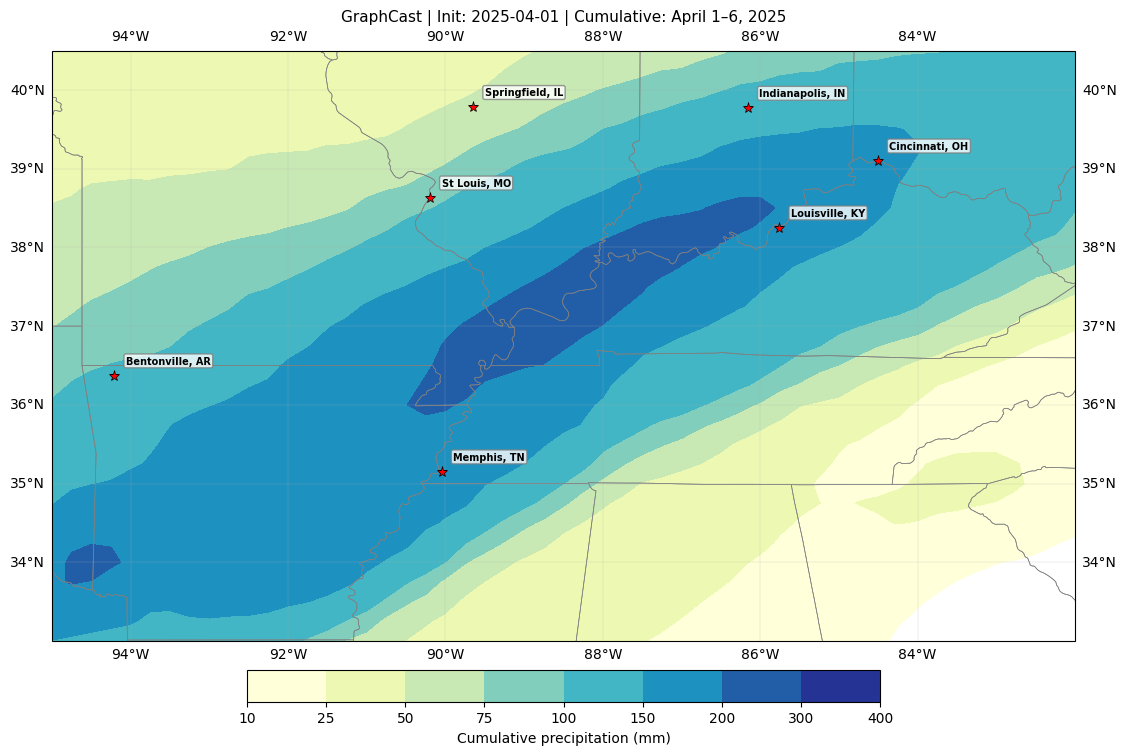

In [44]:
cumulative = compute_cumulative_precip(io, DATES, FORECAST_INIT)

plt.close("all")

lon = io["lon"][:]
lat = io["lat"][:]

levels = [10, 25, 50, 75, 100, 150, 200, 300, 400]
cmap = plt.cm.YlGnBu
norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(12, 8),
)

im = ax.contourf(
    lon, lat, cumulative,
    levels=levels, cmap=cmap, norm=norm,
    transform=ccrs.PlateCarree(), extend="neither",
)

ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.coastlines(linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
ax.set_extent(EXTENT)

for city in CITIES:
    ax.plot(
        city["lon"] - 360, city["lat"],
        marker="*", color="red", markersize=8,
        markeredgecolor="black", markeredgewidth=0.5,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    ax.text(
        city["lon"] - 360 + 0.15, city["lat"] + 0.15, city["label"],
        fontsize=7, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
        transform=ccrs.PlateCarree(), zorder=5,
    )

cbar = plt.colorbar(im, ax=ax, shrink=0.55, pad=0.04, orientation="horizontal")
cbar.set_label("Cumulative precipitation (mm)")
ax.set_title(
    f"GraphCast | Init: {FORECAST_INIT[:10]} | Cumulative: April 1–6, 2025",
    fontsize=11,
)

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/graphcast_cumulative_apr1_6.png", dpi=150, bbox_inches="tight")
print(f"Saved: {OUTPUT_DIR}/graphcast_cumulative_apr1_6.png")

print(f"\nCumulative at Nashville: {cumulative[lat_idx, lon_idx]:.2f} mm")
plt.show()